# 03 — Model Evaluation & 2026 World Cup Predictions

Loads trained Random Forest and Logistic Regression models, evaluates them on the
held-out test set (2022–2026), and produces the final 2026 WC group-stage predictions.

**Run `python src/features.py` then `python src/train.py` before running this notebook.**

In [2]:
import os
import sys
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from sklearn.calibration import CalibrationDisplay

sys.path.insert(0, '../src')
from features import FEATURE_COLS
from train import time_based_split

sns.set_theme(style='whitegrid', palette='muted')
CLASSES = ['Home Win', 'Away Win', 'Draw']

In [3]:
# Load models and scaler
rf  = joblib.load('../data/models/random_forest.pkl')
lr  = joblib.load('../data/models/logistic_regression.pkl')
scaler = joblib.load('../data/models/scaler.pkl')

# Load model-ready training data (with dates from features CSV for split)
model_ready = pd.read_csv('../data/processed/model_ready.csv')
features_dates = pd.read_csv('../data/processed/historical_results_features.csv',
                              usecols=['date', 'tournament_weight'])
features_dates['date'] = pd.to_datetime(features_dates['date'], errors='coerce')
features_dates = features_dates.dropna(subset=['date']).reset_index(drop=True)

# Re-create the time-based test split
TEST_CUTOFF = '2022-01-01'
X = model_ready[FEATURE_COLS]
y = model_ready['outcome']
test_mask = features_dates['date'] >= TEST_CUTOFF

X_test_rf = X[test_mask].reset_index(drop=True)
X_test_lr = pd.DataFrame(scaler.transform(X_test_rf), columns=FEATURE_COLS)
y_test = y[test_mask].reset_index(drop=True)
test_meta = features_dates[test_mask].reset_index(drop=True)

print(f"Test set size: {len(y_test):,} matches ({TEST_CUTOFF} onward)")
print(y_test.value_counts())

Test set size: 4,012 matches (2022-01-01 onward)
outcome
Home Win    1895
Away Win    1166
Draw         951
Name: count, dtype: int64


## 1. Confusion Matrices

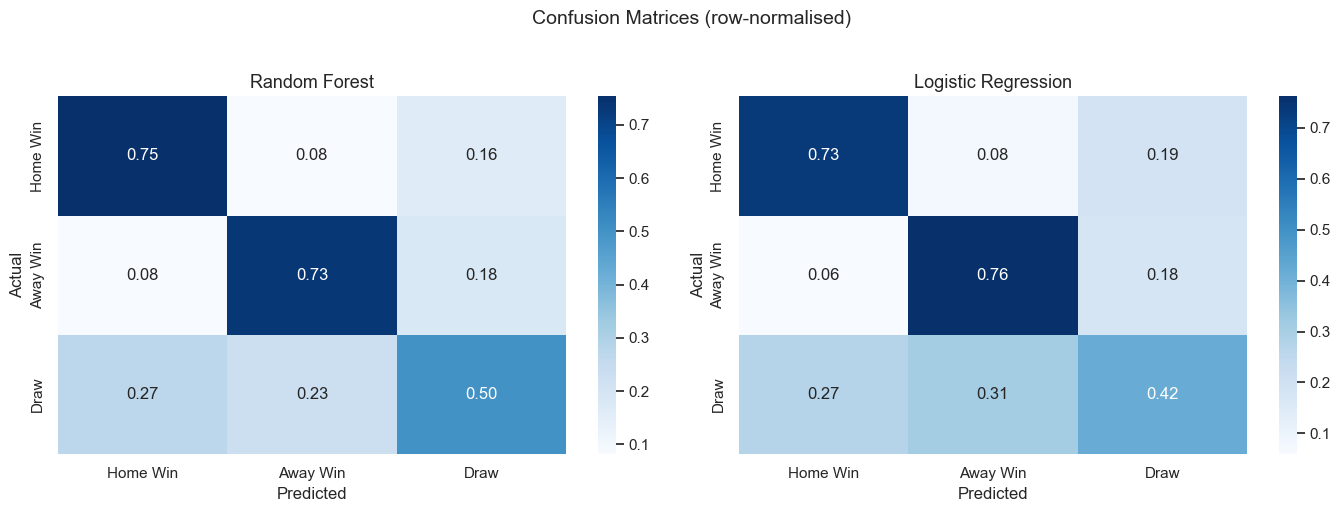

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model, X_t, name in [
    (axes[0], rf, X_test_rf, 'Random Forest'),
    (axes[1], lr, X_test_lr, 'Logistic Regression'),
]:
    cm = confusion_matrix(y_test, model.predict(X_t), labels=CLASSES, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', ax=ax,
                xticklabels=CLASSES, yticklabels=CLASSES)
    ax.set_title(name, fontsize=13)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices (row-normalised)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 2. Classification Report & F1 Comparison

In [5]:
for model, X_t, name in [
    (rf, X_test_rf, 'Random Forest'),
    (lr, X_test_lr, 'Logistic Regression'),
]:
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"  Accuracy: {accuracy_score(y_test, model.predict(X_t)):.4f}  "
          f"F1-macro: {f1_score(y_test, model.predict(X_t), average='macro'):.4f}")
    print('='*55)
    print(classification_report(y_test, model.predict(X_t), labels=CLASSES))


  Random Forest
  Accuracy: 0.6879  F1-macro: 0.6596
              precision    recall  f1-score   support

    Home Win       0.80      0.75      0.78      1895
    Away Win       0.70      0.73      0.72      1166
        Draw       0.47      0.50      0.49       951

    accuracy                           0.69      4012
   macro avg       0.66      0.66      0.66      4012
weighted avg       0.69      0.69      0.69      4012


  Logistic Regression
  Accuracy: 0.6665  F1-macro: 0.6317
              precision    recall  f1-score   support

    Home Win       0.81      0.73      0.77      1895
    Away Win       0.67      0.76      0.71      1166
        Draw       0.41      0.42      0.41       951

    accuracy                           0.67      4012
   macro avg       0.63      0.64      0.63      4012
weighted avg       0.67      0.67      0.67      4012



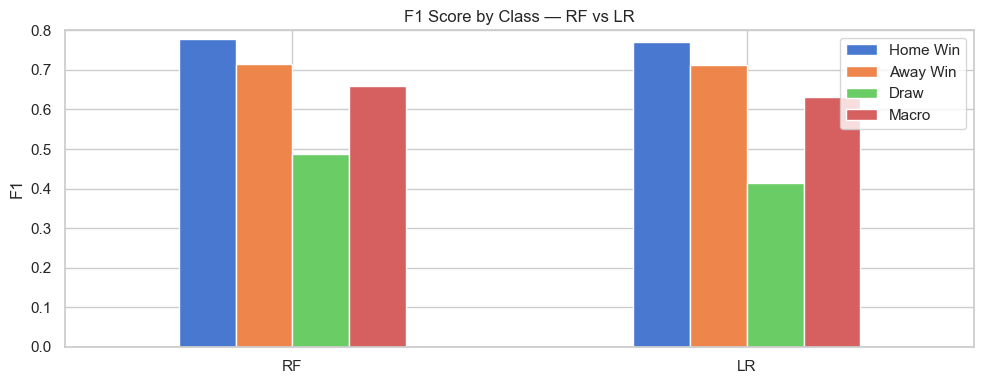

In [6]:
# Bar chart: per-class F1 comparison
metrics = {}
for model, X_t, name in [(rf, X_test_rf, 'RF'), (lr, X_test_lr, 'LR')]:
    f1s = f1_score(y_test, model.predict(X_t), average=None, labels=CLASSES)
    metrics[name] = {cls: f1 for cls, f1 in zip(CLASSES, f1s)}
    metrics[name]['Macro'] = f1_score(y_test, model.predict(X_t), average='macro')

df_metrics = pd.DataFrame(metrics).T
df_metrics.plot(kind='bar', figsize=(10, 4), rot=0, edgecolor='white')
plt.title('F1 Score by Class — RF vs LR')
plt.ylabel('F1')
plt.ylim(0, 0.8)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 3. Probability Calibration

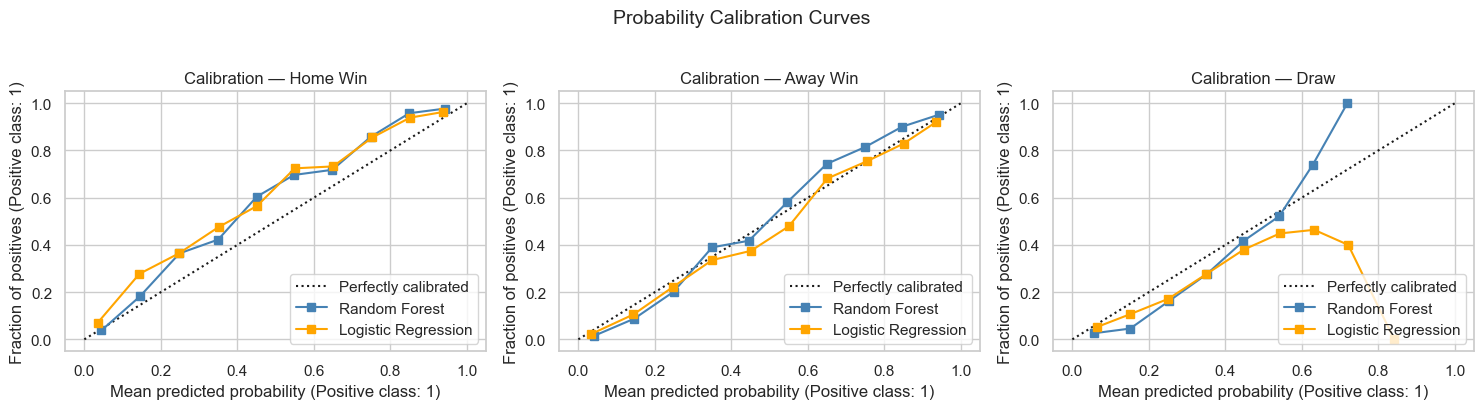

In [7]:
from sklearn.preprocessing import label_binarize

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
y_bin = label_binarize(y_test, classes=CLASSES)

rf_classes = list(rf.classes_)
lr_classes = list(lr.classes_)

for i, cls in enumerate(CLASSES):
    ax = axes[i]
    rf_col = rf_classes.index(cls)
    lr_col = lr_classes.index(cls)

    CalibrationDisplay.from_predictions(
        y_bin[:, i], rf.predict_proba(X_test_rf)[:, rf_col],
        n_bins=10, ax=ax, name='Random Forest', color='steelblue'
    )
    CalibrationDisplay.from_predictions(
        y_bin[:, i], lr.predict_proba(X_test_lr)[:, lr_col],
        n_bins=10, ax=ax, name='Logistic Regression', color='orange'
    )
    ax.set_title(f'Calibration — {cls}')

plt.suptitle('Probability Calibration Curves', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4. Feature Importance

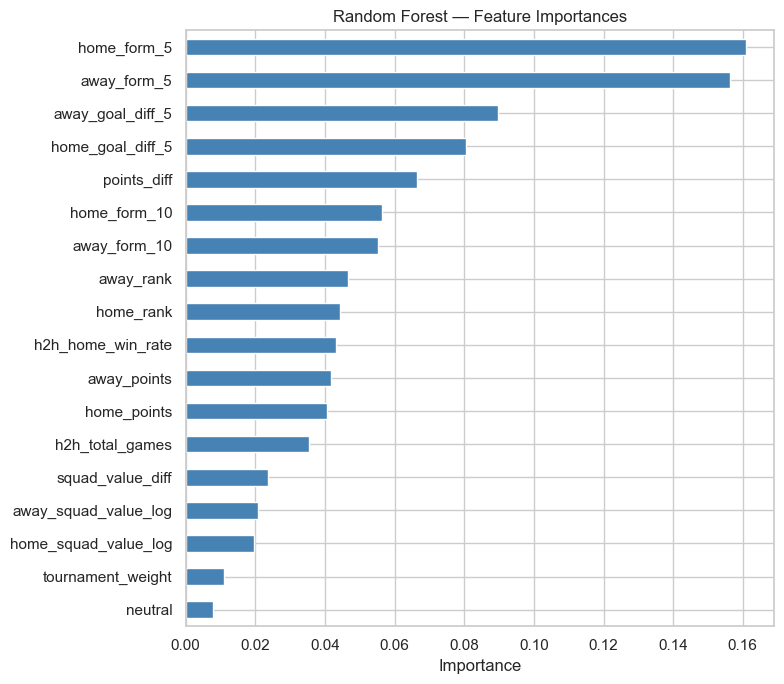

In [8]:
# RF feature importances
importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
importances.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Random Forest — Feature Importances')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

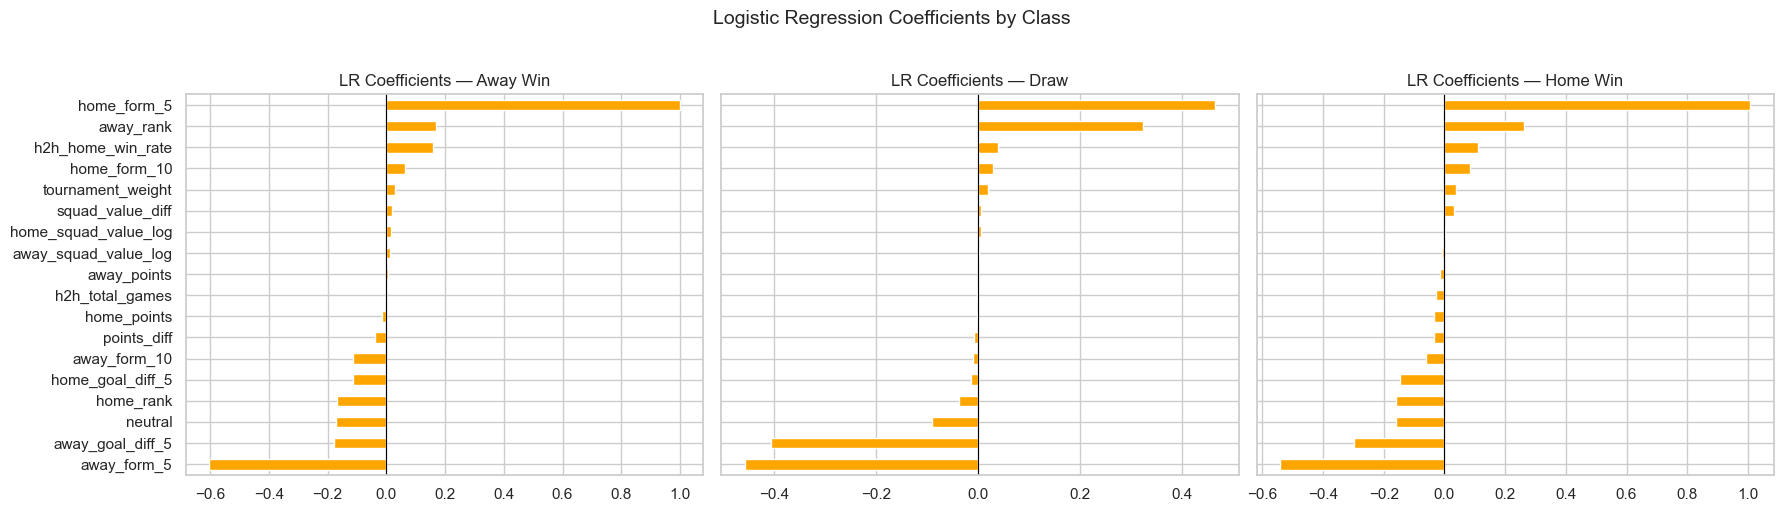

In [9]:
# LR coefficient magnitudes per class
coef_df = pd.DataFrame(lr.coef_, columns=FEATURE_COLS, index=lr.classes_)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, cls in zip(axes, lr.classes_):
    coef_df.loc[cls].sort_values().plot(kind='barh', ax=ax, color='orange', edgecolor='white')
    ax.set_title(f'LR Coefficients — {cls}')
    ax.axvline(0, color='black', linewidth=0.8)

plt.suptitle('Logistic Regression Coefficients by Class', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5. Accuracy by Tournament Type

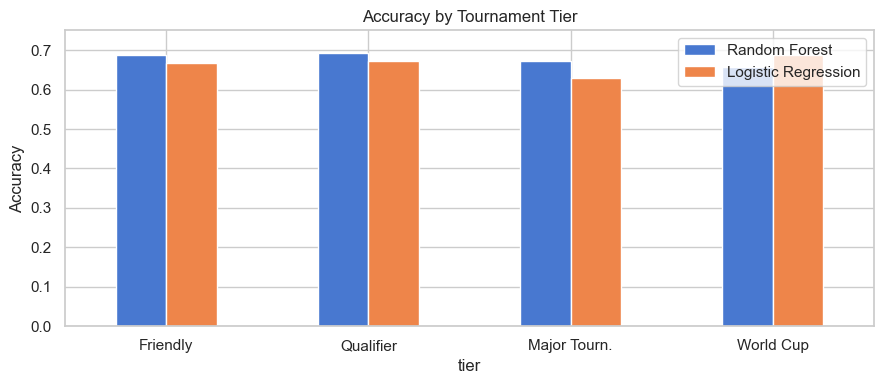

              Random Forest  Logistic Regression
tier                                            
Friendly              0.688                0.667
Qualifier             0.693                0.672
Major Tourn.          0.672                0.629
World Cup             0.656                0.688


In [10]:
results_test = test_meta.copy()
results_test['actual'] = y_test.values
results_test['rf_pred'] = rf.predict(X_test_rf)
results_test['lr_pred'] = lr.predict(X_test_lr)
results_test['rf_correct'] = (results_test['actual'] == results_test['rf_pred']).astype(int)
results_test['lr_correct'] = (results_test['actual'] == results_test['lr_pred']).astype(int)

tier_labels = {1: 'Friendly', 2: 'Qualifier', 3: 'Major Tourn.', 4: 'World Cup'}
results_test['tier'] = results_test['tournament_weight'].map(tier_labels)

acc_by_tier = results_test.groupby('tier')[['rf_correct', 'lr_correct']].mean()
acc_by_tier.columns = ['Random Forest', 'Logistic Regression']
acc_by_tier = acc_by_tier.reindex(['Friendly', 'Qualifier', 'Major Tourn.', 'World Cup'])

acc_by_tier.plot(kind='bar', figsize=(9, 4), rot=0, edgecolor='white')
plt.title('Accuracy by Tournament Tier')
plt.ylabel('Accuracy')
plt.ylim(0, 0.75)
plt.legend()
plt.tight_layout()
plt.show()
print(acc_by_tier.round(3))

## 6. Error Analysis — Top Upsets Both Models Missed

In [11]:
# Load full test rows (with team names) from features CSV
features_full = pd.read_csv('../data/processed/historical_results_features.csv')
features_full['date'] = pd.to_datetime(features_full['date'], errors='coerce')
features_full = features_full.dropna(subset=['date']).reset_index(drop=True)
test_full = features_full[features_full['date'] >= TEST_CUTOFF].reset_index(drop=True)

test_full['rf_pred'] = rf.predict(X_test_rf)
test_full['lr_pred'] = lr.predict(X_test_lr)
test_full['rf_prob_pred'] = rf.predict_proba(X_test_rf).max(axis=1)

both_wrong = test_full[
    (test_full['outcome'] != test_full['rf_pred']) &
    (test_full['outcome'] != test_full['lr_pred'])
].copy()

upsets = both_wrong.sort_values('rf_prob_pred', ascending=False).head(20)
print(f"Both models wrong on {len(both_wrong):,} of {len(test_full):,} test matches ({len(both_wrong)/len(test_full):.1%})")
upsets[['date', 'home_team', 'away_team', 'outcome', 'rf_pred', 'lr_pred',
         'points_diff', 'rf_prob_pred']].round(2)

Both models wrong on 2,137 of 4,012 test matches (53.3%)


/var/folders/57/1yhv43hx6tl7nz22346tzzs80000gn/T/ipykernel_61049/976371385.py:19: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  'points_diff', 'rf_prob_pred']].round(2)


,date,home_team,away_team,outcome,rf_pred,lr_pred,points_diff,rf_prob_pred
3441,2025-10-09,Malta,Netherlands,Away Win,Home Win,Home Win,-771.74,1.00
1545,2023-10-17,North Macedonia,Armenia,Home Win,Away Win,Away Win,108.48,0.99
3121,2025-06-06,Hungary,Sweden,Away Win,Home Win,Home Win,-32.71,0.99
3499,2025-10-12,Malta,Bosnia and Herzegovina,Away Win,Home Win,Home Win,-361.82,0.99
1636,2023-11-16,Qatar,Afghanistan,Home Win,Away Win,Away Win,360.36,0.99
3693,2025-11-18,Maldives,Philippines,Away Win,Home Win,Home Win,-126.91,0.99
2114,2024-06-06,Egypt,Burkina Faso,Home Win,Away Win,Away Win,109.34,0.98
1459,2023-10-12,Singapore,Guam,Home Win,Away Win,Away Win,178.14,0.98
1715,2023-11-21,Ethiopia,Burkina Faso,Away Win,Home Win,Home Win,-338.05,0.98
1381,2023-09-10,Nigeria,São Tomé and Príncipe,Home Win,Away Win,Away Win,586.41,0.98


## 7. 2026 World Cup Predictions

In [12]:
predictions = pd.read_csv('../data/processed/predictions.csv')
predictions['date'] = pd.to_datetime(predictions['date'])

print(f"Total fixtures: {len(predictions)}")
print(f"\nRF prediction distribution:\n{predictions['rf_prediction'].value_counts()}")
print(f"\nLR prediction distribution:\n{predictions['lr_prediction'].value_counts()}")
print(f"\nAgreements: {(predictions['rf_prediction'] == predictions['lr_prediction']).sum()} / {len(predictions)}")

Total fixtures: 72

RF prediction distribution:
rf_prediction
Home Win    27
Away Win    26
Draw        19
Name: count, dtype: int64

LR prediction distribution:
lr_prediction
Away Win    28
Home Win    26
Draw        18
Name: count, dtype: int64

Agreements: 59 / 72


In [13]:
# Display all predictions sorted by date
display_cols = ['date', 'home_team', 'away_team',
                'rf_prediction', 'rf_home_win_prob', 'rf_draw_prob', 'rf_away_win_prob',
                'lr_prediction', 'lr_home_win_prob', 'lr_draw_prob', 'lr_away_win_prob']

pd.set_option('display.max_rows', 80)
pd.set_option('display.float_format', '{:.2f}'.format)
predictions[display_cols].sort_values('date')

,date,home_team,away_team,rf_prediction,rf_home_win_prob,rf_draw_prob,rf_away_win_prob,lr_prediction,lr_home_win_prob,lr_draw_prob,lr_away_win_prob
0,2026-06-11,Mexico,South Africa,Home Win,0.61,0.34,0.05,Home Win,0.78,0.20,0.02
1,2026-06-11,Korea Republic,Czechia,Away Win,0.08,0.42,0.50,Away Win,0.08,0.37,0.55
2,2026-06-12,Canada,Bosnia and Herzegovina,Home Win,0.46,0.40,0.14,Home Win,0.47,0.41,0.12
3,2026-06-12,USA,Paraguay,Away Win,0.27,0.30,0.42,Draw,0.32,0.38,0.30
4,2026-06-13,Qatar,Switzerland,Away Win,0.03,0.29,0.68,Away Win,0.01,0.23,0.77
5,2026-06-13,Brazil,Morocco,Away Win,0.10,0.36,0.54,Away Win,0.09,0.40,0.51
6,2026-06-13,Haiti,Scotland,Draw,0.20,0.46,0.34,Draw,0.13,0.57,0.30
7,2026-06-13,Australia,Türkiye,Away Win,0.02,0.30,0.68,Away Win,0.01,0.13,0.86
11,2026-06-14,Sweden,Tunisia,Away Win,0.06,0.23,0.70,Away Win,0.03,0.13,0.84
10,2026-06-14,Netherlands,Japan,Draw,0.27,0.52,0.21,Draw,0.34,0.42,0.23


In [14]:
# Highlight disagreements between the two models
disagreements = predictions[predictions['rf_prediction'] != predictions['lr_prediction']]
print(f"Fixtures where RF and LR disagree: {len(disagreements)}")
disagreements[['date', 'home_team', 'away_team', 'rf_prediction', 'lr_prediction',
               'rf_home_win_prob', 'rf_draw_prob', 'rf_away_win_prob']].sort_values('date')

Fixtures where RF and LR disagree: 13


,date,home_team,away_team,rf_prediction,lr_prediction,rf_home_win_prob,rf_draw_prob,rf_away_win_prob
3,2026-06-12,USA,Paraguay,Away Win,Draw,0.27,0.30,0.42
14,2026-06-15,Spain,Cabo Verde,Home Win,Draw,0.49,0.40,0.11
22,2026-06-17,England,Croatia,Home Win,Draw,0.42,0.33,0.25
25,2026-06-18,Mexico,Korea Republic,Draw,Home Win,0.33,0.56,0.10
26,2026-06-18,Switzerland,Bosnia and Herzegovina,Home Win,Draw,0.46,0.38,0.16
28,2026-06-19,Scotland,Morocco,Draw,Home Win,0.33,0.41,0.26
41,2026-06-22,Norway,Senegal,Home Win,Draw,0.38,0.31,0.32
42,2026-06-22,Argentina,Austria,Draw,Home Win,0.34,0.40,0.25
45,2026-06-23,Colombia,Congo DR,Draw,Away Win,0.29,0.39,0.33
59,2026-06-25,Tunisia,Netherlands,Draw,Away Win,0.07,0.58,0.35
